In [45]:
import pandas as pd

sales = pd.read_csv("../data/processed/daily_sales.csv")
sales["date"] = pd.to_datetime(sales["date"])

sales.head()


C:\Users\balis\AppData\Local\Temp\ipykernel_51932\33663676.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv("../data/processed/daily_sales.csv")


,StockCode,date,Quantity,day_of_week,month
0,10002,2009-12-01,12,1,12
1,10002,2009-12-03,7,3,12
2,10002,2009-12-04,73,4,12
3,10002,2009-12-06,49,6,12
4,10002,2009-12-07,2,0,12


In [46]:
product_id = sales["StockCode"].value_counts().index[0]

df = sales[sales["StockCode"] == product_id]
df = df.groupby("date")["Quantity"].sum().reset_index()


In [47]:
df_prophet = df.rename(columns={
    "date": "ds",
    "Quantity": "y"
})


In [48]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(df_prophet)


21:17:46 - cmdstanpy - INFO - Chain [1] start processing
21:17:47 - cmdstanpy - INFO - Chain [1] done processing


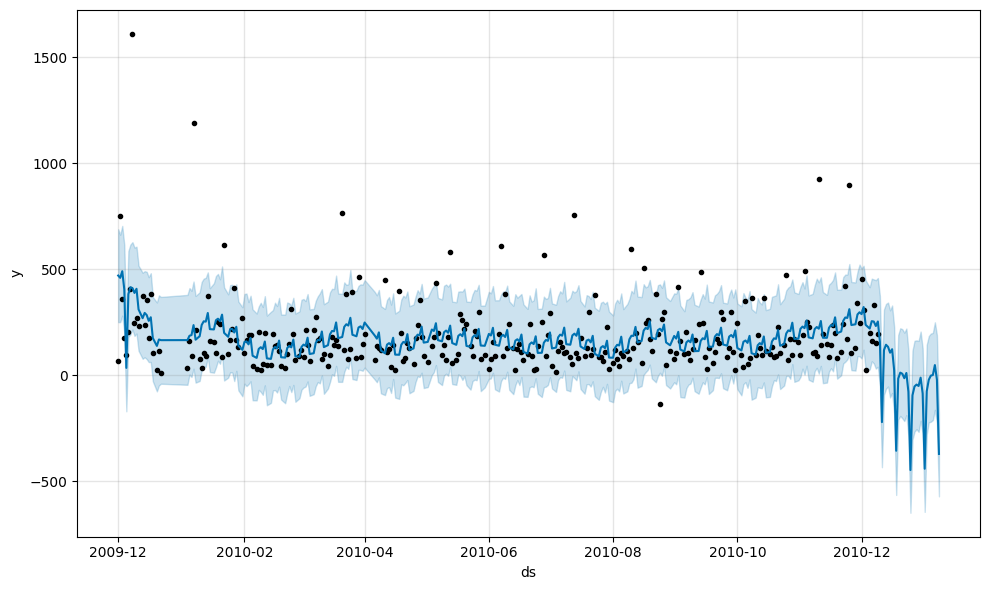

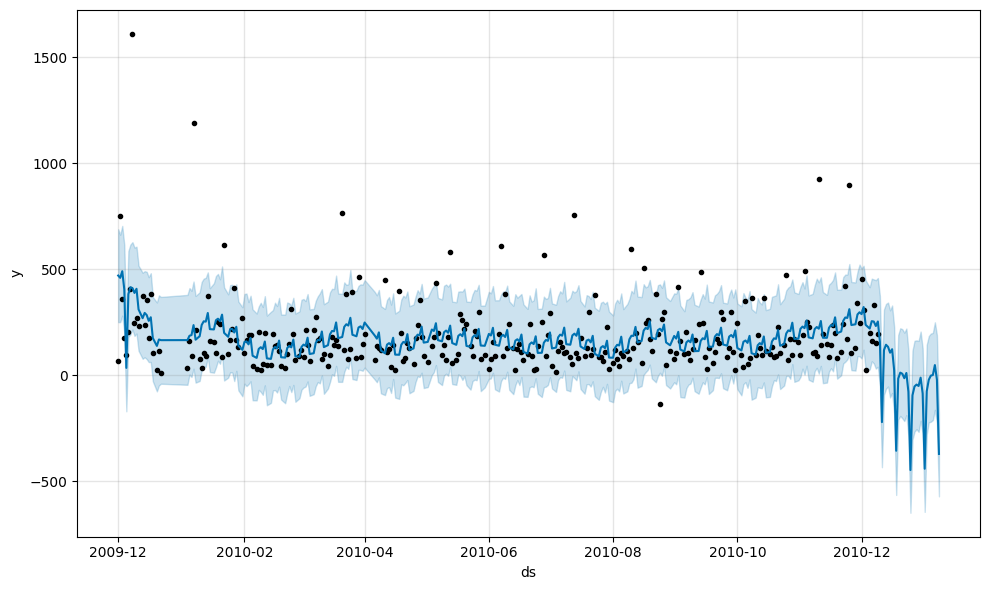

In [49]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()
model.plot(forecast)


In [50]:
split_date = "2010-09-01"

train = df_prophet[df_prophet["ds"] < split_date]
test  = df_prophet[df_prophet["ds"] >= split_date]


In [51]:
print(len(train), len(test))


220 86


In [52]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)


21:17:47 - cmdstanpy - INFO - Chain [1] start processing
21:17:47 - cmdstanpy - INFO - Chain [1] done processing


In [53]:
future = model.make_future_dataframe(
    periods=len(test),   # forecast length = test length
    freq="D"
)


In [54]:
forecast = model.predict(future)


In [55]:
forecast_test = forecast.tail(len(test))

forecast_test = forecast_test[["ds", "yhat"]]


In [56]:
evaluation_df = test.merge(
    forecast_test,
    on="ds",
    how="left"
)

evaluation_df.head()


,ds,y,yhat
0,2010-09-01,107,86.809339
1,2010-09-02,417,118.395050
2,2010-09-03,162,27.740052
3,2010-09-05,101,23.671954
4,2010-09-06,205,49.197232


In [57]:
evaluation_df = forecast[["ds","yhat"]].merge(
    df_prophet,
    on="ds",
    how="inner"
)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    evaluation_df["y"],
    evaluation_df["yhat"]
)

print("MAE:", mae)


MAE: 110.40398819207225


In [58]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(
    evaluation_df["y"],
    evaluation_df["yhat"]
))

print("RMSE:", rmse)


RMSE: 173.67842360992512


In [59]:
mape = (
    abs(evaluation_df["y"] - evaluation_df["yhat"])
    / evaluation_df["y"]
).mean() * 100

print("MAPE:", mape, "%")


MAPE: 86.97053491636343 %


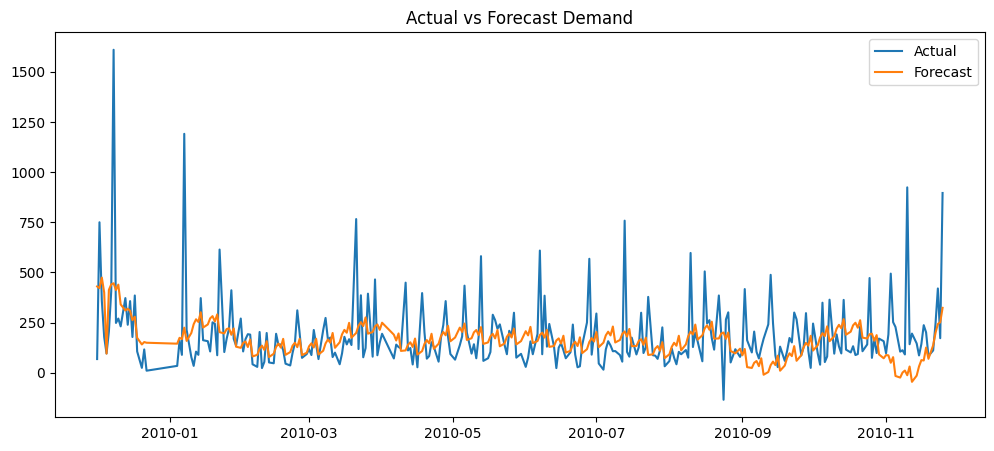

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    evaluation_df["ds"],
    evaluation_df["y"],
    label="Actual"
)

plt.plot(
    evaluation_df["ds"],
    evaluation_df["yhat"],
    label="Forecast"
)

plt.legend()
plt.title("Actual vs Forecast Demand")
plt.show()


In [61]:
import numpy as np

def create_sequences(data, seq_len=30):
    X, y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])

    return np.array(X), np.array(y)


In [62]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df["Quantity"].values.reshape(-1,1)
)


In [63]:
SEQ_LEN = 30

X, y = create_sequences(scaled_data, SEQ_LEN)

print(X.shape, y.shape)


(276, 30, 1) (276, 1)


In [64]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [65]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


In [66]:
import torch.nn as nn

class LSTMForecast(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = self.fc(out[:, -1, :])

        return out


In [67]:
model = LSTMForecast()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [68]:
EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")


Epoch 1 Loss: 0.0520
Epoch 2 Loss: 0.0453
Epoch 3 Loss: 0.0390
Epoch 4 Loss: 0.0332
Epoch 5 Loss: 0.0277
Epoch 6 Loss: 0.0227
Epoch 7 Loss: 0.0182
Epoch 8 Loss: 0.0142
Epoch 9 Loss: 0.0108
Epoch 10 Loss: 0.0082
Epoch 11 Loss: 0.0065
Epoch 12 Loss: 0.0058
Epoch 13 Loss: 0.0061
Epoch 14 Loss: 0.0073
Epoch 15 Loss: 0.0087
Epoch 16 Loss: 0.0096
Epoch 17 Loss: 0.0098
Epoch 18 Loss: 0.0094
Epoch 19 Loss: 0.0085
Epoch 20 Loss: 0.0077


In [69]:
model.eval()

with torch.no_grad():

    preds = model(X_test).numpy()


In [70]:
preds_actual = scaler.inverse_transform(preds)
y_test_actual = scaler.inverse_transform(y_test.numpy())


In [71]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    preds_actual
)

rmse = np.sqrt(
    ((y_test_actual - preds_actual) ** 2).mean()
)

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 123.10716247558594
RMSE: 173.95901


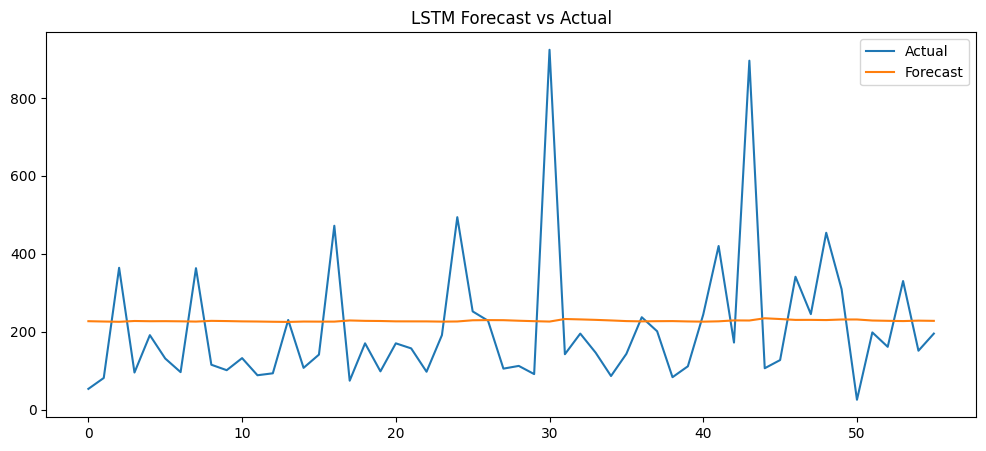

In [72]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(preds_actual, label="Forecast")

plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()


In [73]:
import pandas as pd

data = pd.read_csv("../data/processed/daily_sales.csv")

data["date"] = pd.to_datetime(data["date"])

data.head()


C:\Users\balis\AppData\Local\Temp\ipykernel_51932\283335371.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/processed/daily_sales.csv")


,StockCode,date,Quantity,day_of_week,month
0,10002,2009-12-01,12,1,12
1,10002,2009-12-03,7,3,12
2,10002,2009-12-04,73,4,12
3,10002,2009-12-06,49,6,12
4,10002,2009-12-07,2,0,12


In [74]:
data = data.sort_values("date")

data["time_idx"] = (
    data["date"] - data["date"].min()
).dt.days


In [75]:
data.rename(
    columns={
        "StockCode": "product_id",
        "Quantity": "sales"
    },
    inplace=True
)


In [76]:
data["day_of_week"] = data["date"].dt.dayofweek
data["month"] = data["date"].dt.month


In [77]:
max_time = data["time_idx"].max()

training_cutoff = max_time - 30  # last 30 days validation


In [78]:
data.dtypes


product_id             object
date           datetime64[ns]
sales                   int64
day_of_week             int32
month                   int32
time_idx                int64
dtype: object

In [79]:
data["product_id"] = data["product_id"].astype(str)

In [80]:
data.groupby("product_id")["time_idx"].diff().value_counts()


time_idx
1.0      127461
2.0       48848
3.0       24525
4.0       14788
5.0        9879
          ...  
234.0         1
301.0         1
263.0         1
314.0         1
179.0         1
Name: count, Length: 267, dtype: int64

In [81]:
data["time_idx"] = (
    data["date"]
    .rank(method="dense")
    .astype(int)
)


In [82]:
data.groupby("product_id")["time_idx"].diff().max()


np.float64(287.0)

In [83]:
data.groupby("product_id").size().describe()


count    4632.000000
mean       58.728627
std        66.508303
min         1.000000
25%         9.000000
50%        33.000000
75%        86.000000
max       306.000000
dtype: float64

In [84]:
data.isna().sum()


product_id     0
date           0
sales          0
day_of_week    0
month          0
time_idx       0
dtype: int64

In [85]:
data = data.sort_values(["product_id","time_idx"])


In [86]:
# Core
import pandas as pd
import numpy as np

# PyTorch
import torch
import torch.nn as nn

# Forecasting
from pytorch_forecasting import (
    TimeSeriesDataSet,
    TemporalFusionTransformer
)

from pytorch_forecasting.metrics import QuantileLoss

# Lightning (modern)
from lightning.pytorch import Trainer


In [87]:
training = TimeSeriesDataSet(
    data[data.time_idx <= training_cutoff],

    time_idx="time_idx",
    target="sales",
    group_ids=["product_id"],

    max_encoder_length=30,
    max_prediction_length=7,

    time_varying_known_reals=[
        "time_idx",
        "day_of_week",
        "month"
    ],

    time_varying_unknown_reals=["sales"],

    allow_missing_timesteps=True
)


c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 1550 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__product_id': '10002R'}, {'__group_id__product_id': '10080'}, {'__group_id__product_id': '10109'}, {'__group_id__product_id': '10123G'}, {'__group_id__product_id': '10124A'}, {'__group_id__product_id': '10124C'}, {'__group_id__product_id': '10124G'}, {'__group_id__product_id': '15002'}, {'__group_id__product_id': '15056p'}, {'__group_id__product_id': '15059A'}]
  warnings.warn(


In [88]:
validation = TimeSeriesDataSet.from_dataset(
    training,
    data,
    predict=True,
    stop_randomization=True
)


c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 3554 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__product_id': '10002'}, {'__group_id__product_id': '10002R'}, {'__group_id__product_id': '10080'}, {'__group_id__product_id': '10109'}, {'__group_id__product_id': '10120'}, {'__group_id__product_id': '10123C'}, {'__group_id__product_id': '10123G'}, {'__group_id__product_id': '10124A'}, {'__group_id__product_id': '10124C'}, {'__group_id__product_id': '10124G'}]
  warnings.warn(


In [89]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = training.to_dataloader(
    train=True,
    batch_size=batch_size
)

val_loader = validation.to_dataloader(
    train=False,
    batch_size=batch_size
)


In [90]:
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_lightning import Trainer

tft = TemporalFusionTransformer.from_dataset(
    training,

    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,

    loss=QuantileLoss(),

    log_interval=10,
)


c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [91]:
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min"
)

trainer = Trainer(
    max_epochs=5,
    accelerator="cpu",
    gradient_clip_val=0.1,
    callbacks=[early_stop],
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [92]:
trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      | train | 0    
3  | prescalers                         | ModuleDict                      | 64     | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 0      | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 2.4 K  | train | 0 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_w

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


In [93]:
predictions = tft.predict(
    val_loader,
    return_index=True,
    return_decoder_lengths=True
)


c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


In [94]:
preds  = predictions.output
index  = predictions.index


In [95]:
print(type(preds))
print(preds.shape)

print(type(index))
print(index.head())


<class 'torch.Tensor'>
torch.Size([1078, 7])
<class 'pandas.core.frame.DataFrame'>
   time_idx product_id
0       301      15036
1       301    15056BL
2       301     15056N
3       297     15056P
4       301    15056bl


In [96]:
import pandas as pd

forecast_list = []

for i in range(len(preds)):

    product = index.iloc[i]["product_id"]
    start_time = index.iloc[i]["time_idx"]

    for step in range(preds.shape[1]):

        forecast_list.append({
            "product_id": product,
            "time_idx": start_time + step,
            "forecast_qty": float(preds[i, step])
        })

forecast_df = pd.DataFrame(forecast_list)


In [97]:
date_map = data[["time_idx", "date"]].drop_duplicates()

forecast_df = forecast_df.merge(
    date_map,
    on="time_idx",
    how="left"
)


In [98]:
forecast_df = forecast_df[
    ["product_id", "date", "forecast_qty"]
]

forecast_df.head()


,product_id,date,forecast_qty
0,15036,2010-12-02,390.560852
1,15036,2010-12-03,388.549164
2,15036,2010-12-05,387.367249
3,15036,2010-12-06,389.851990
4,15036,2010-12-07,389.752441


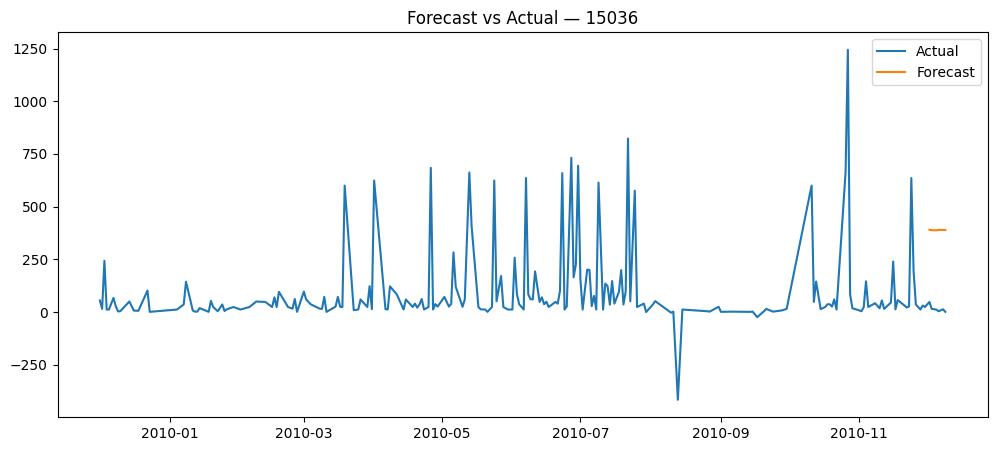

In [99]:
product = forecast_df["product_id"].iloc[0]

actual = data[data["product_id"] == product]
pred   = forecast_df[forecast_df["product_id"] == product]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(actual["date"], actual["sales"], label="Actual")
plt.plot(pred["date"], pred["forecast_qty"], label="Forecast")

plt.legend()
plt.title(f"Forecast vs Actual — {product}")
plt.show()


c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\ml-projects\enterprise-retail-ai\venv2\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x200 with 1 Axes>,
 'encoder_variables': <Figure size 700x300 with 1 Axes>,
 'decoder_variables': <Figure size 700x275 with 1 Axes>}

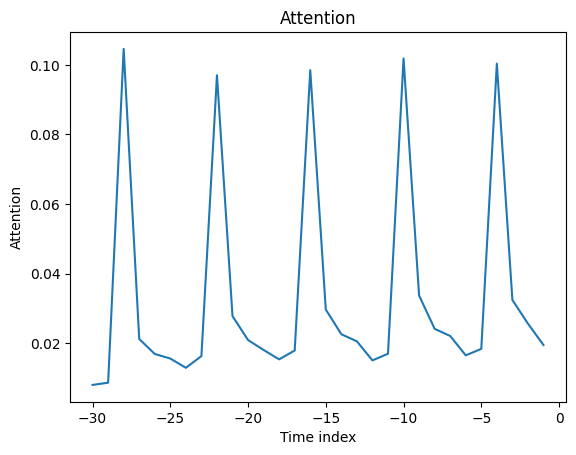

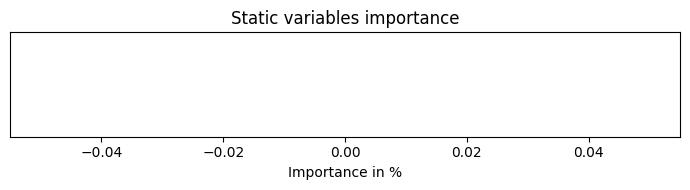

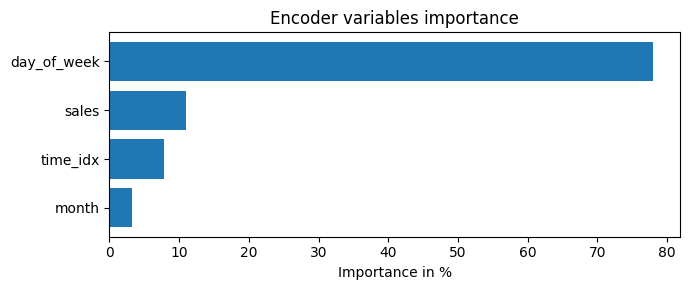

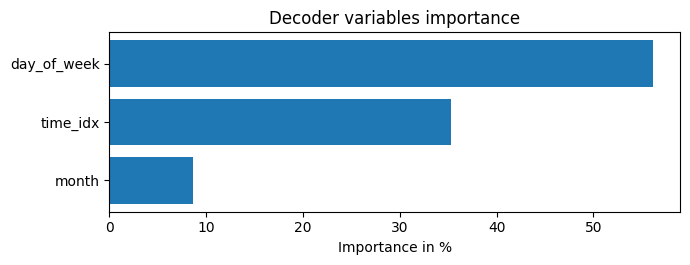

In [100]:
raw_output = tft.predict(
    val_loader,
    mode="raw",
    return_x=True
)
raw_preds = raw_output.output
interpretation = tft.interpret_output(
    raw_preds,
    reduction="sum"
)
tft.plot_interpretation(interpretation)



In [101]:
forecast_df.to_csv(
    "../data/processed/forecast_tft_final.csv",
    index=False
)


In [104]:
trainer.save_checkpoint(
    "../forecasting/tft_model.ckpt"
)


`weights_only` was not set, defaulting to `False`.
